### Step 1 — Mount Drive and define paths

In [1]:
# Step 1: Mount Google Drive and define paths

from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
PHASE3_DIR = BASE_DIR / "analysis" / "phase3"
OUT_DIR = BASE_DIR / "analysis" / "phase3_error_analysis"

OUT_DIR.mkdir(parents=True, exist_ok=True)

VAL_MANIFEST_PHASE3 = SPLIT_DIR / "train_pairs_3d_val_phase3_500.json"
BEST_CKPT_PATH = CKPT_DIR / "conditional_unet3d_flow_phase3_train2000_val500_ep50_best.pt"
TRAINING_SUMMARY_PATH = PHASE3_DIR / "phase3_flow_training_summary.json"

print("BASE_DIR exists:", BASE_DIR.exists())
print("VAL_MANIFEST exists:", VAL_MANIFEST_PHASE3.exists())
print("BEST_CKPT exists:", BEST_CKPT_PATH.exists())
print("TRAINING_SUMMARY exists:", TRAINING_SUMMARY_PATH.exists())
print("OUT_DIR exists:", OUT_DIR.exists())

Mounted at /content/drive
BASE_DIR exists: True
VAL_MANIFEST exists: True
BEST_CKPT exists: True
TRAINING_SUMMARY exists: True
OUT_DIR exists: True


### Step 2 — Imports

In [2]:
# Step 2: Imports

import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from torch.utils.data import DataLoader

### Step 3 — Reuse dataset and model definitions

In [3]:
# Step 3: Reuse existing definitions
# Required before continuing:
# - CubePair3DDataset
# - ConditionalUNetFlow3D
# - euler_sample_flow_3d
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)   # (1,D,H,W)
        x1 = torch.from_numpy(x1).unsqueeze(0)   # (1,D,H,W)

        return x0, x1


class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)



class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        # xt, x0: (B,1,D,H,W)
        # t:      (B,1,1,1,1)
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])  # (B,1,D,H,W)
        inp = torch.cat([xt, x0, t_map], dim=1)  # (B,3,D,H,W)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b  = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)  # predicted velocity


@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    """
    x0: (B,1,D,H,W)
    """
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z

### Step 4 — Load validation dataset and best checkpoint

In [4]:
# Step 4: Load validation dataset and best checkpoint

DOSE_SCALE = 1000.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

val_dataset_3d = CubePair3DDataset(VAL_MANIFEST_PHASE3, dose_scale=DOSE_SCALE)
val_loader_3d = DataLoader(val_dataset_3d, batch_size=1, shuffle=False, num_workers=0)

best_ckpt = torch.load(BEST_CKPT_PATH, map_location="cpu")
flow_model = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=24).to(device)
flow_model.load_state_dict(best_ckpt["model_state_dict"])
flow_model.eval()

print("Using device:", device)
print("Validation dataset length:", len(val_dataset_3d))
print("Checkpoint loaded successfully.")

Using device: cuda
Validation dataset length: 500
Checkpoint loaded successfully.


### Step 5 — Plot the loss curve with professor-requested y-scale

Train losses available: True
Val losses available: True


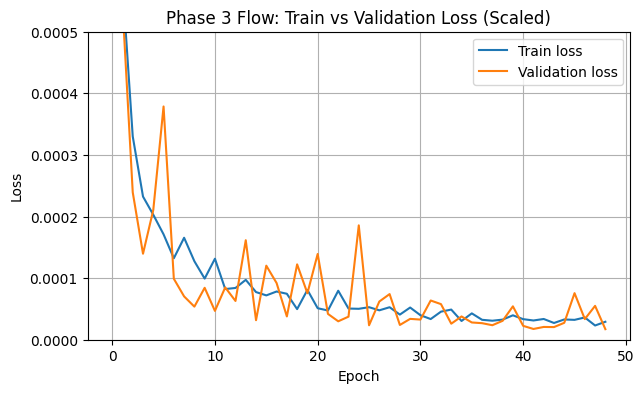

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_error_analysis/phase3_flow_train_val_loss_scaled_0_to_5e-4.png


In [5]:
# Step 5: Plot the train/validation loss with y-axis scaled to 0 ... 5e-4

with open(TRAINING_SUMMARY_PATH, "r", encoding="utf-8") as f:
    training_summary = json.load(f)

train_losses = best_ckpt.get("train_losses", None)
val_losses = best_ckpt.get("val_losses", None)

print("Train losses available:", train_losses is not None)
print("Val losses available:", val_losses is not None)

def plot_scaled_loss_curve(train_losses, val_losses, save_path):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(train_losses, label="Train loss")
    ax.plot(val_losses, label="Validation loss")
    ax.set_title("Phase 3 Flow: Train vs Validation Loss (Scaled)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_ylim(0.0, 5e-4)
    ax.grid(True)
    ax.legend()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

plot_scaled_loss_curve(
    train_losses,
    val_losses,
    OUT_DIR / "phase3_flow_train_val_loss_scaled_0_to_5e-4.png"
)

### Step 6 — Helper functions for prediction and slice selection

In [6]:
# Step 6: Helper functions for prediction and slice selection

@torch.no_grad()
def get_flow_prediction(model, dataset, idx, device, n_steps=30):
    x0, x1 = dataset[idx]
    x0_t = x0.unsqueeze(0).to(device)
    pred = euler_sample_flow_3d(model, x0_t, n_steps=n_steps).cpu().squeeze().numpy()

    ct_vol = x0.squeeze().numpy()
    gt_vol = x1.squeeze().numpy()
    return ct_vol, gt_vol, pred


def find_best_dose_slice_index(volume):
    """
    Find the slice index with the largest total dose intensity.
    """
    slice_sums = volume.reshape(volume.shape[0], -1).sum(axis=1)
    return int(np.argmax(slice_sums))


def find_peak_xy(volume, slice_idx):
    """
    Find the (y, x) location of the maximum value on a given slice.
    """
    slice_2d = volume[slice_idx]
    peak_idx = np.unravel_index(np.argmax(slice_2d), slice_2d.shape)
    return peak_idx  # (y, x)

### Step 7 — Compute validation-wide metrics table

In [7]:
# Step 7: Compute validation-wide metrics table

EPS = 1e-8
all_rows = []

for idx in range(len(val_dataset_3d)):
    ct_vol, gt_vol, pred_vol = get_flow_prediction(flow_model, val_dataset_3d, idx, device, n_steps=30)

    mse = float(np.mean((pred_vol - gt_vol) ** 2))
    mae = float(np.mean(np.abs(pred_vol - gt_vol)))
    rel_err_pct = float(100.0 * np.sum(np.abs(pred_vol - gt_vol)) / (np.sum(np.abs(gt_vol)) + EPS))

    slice_idx = find_best_dose_slice_index(gt_vol)
    peak_y, peak_x = find_peak_xy(gt_vol, slice_idx)
    gt_max = float(gt_vol.max())

    all_rows.append({
        "sample_idx": idx,
        "best_slice": slice_idx,
        "peak_y": peak_y,
        "peak_x": peak_x,
        "gt_max": gt_max,
        "mse": mse,
        "mae": mae,
        "relative_error_pct": rel_err_pct,
    })

metrics_df = pd.DataFrame(all_rows)
metrics_df = metrics_df.sort_values("relative_error_pct", ascending=True).reset_index(drop=True)

print(metrics_df.head())
print(metrics_df.describe())

   sample_idx  best_slice  peak_y  peak_x    gt_max       mse       mae  \
0         246          16      16       0  3.552788  0.000005  0.001633   
1         497          16      16       0  1.577799  0.000004  0.001613   
2         467          16      16       0  3.327456  0.000006  0.001689   
3         348          16      16       0  3.400988  0.000006  0.001692   
4         232          16      16       0  3.575972  0.000006  0.001701   

   relative_error_pct  
0            3.464413  
1            3.528279  
2            3.587221  
3            3.592936  
4            3.609208  
       sample_idx  best_slice      peak_y  peak_x      gt_max         mse  \
count  500.000000  500.000000  500.000000   500.0  500.000000  500.000000   
mean   249.500000   16.080000   16.000000     0.0    2.657228    0.000020   
std    144.481833    3.365152    0.126618     0.0    0.729505    0.000014   
min      0.000000    0.000000   15.000000     0.0    1.339004    0.000004   
25%    124.750000   

### Step 8 — Save and inspect the summary table

In [8]:
# Step 8: Save and inspect the summary table

metrics_csv_path = OUT_DIR / "phase3_validation_metrics_table.csv"
metrics_df.to_csv(metrics_csv_path, index=False)

print("Saved:", metrics_csv_path)

print("\nBest 5 samples by relative error percentage:")
print(metrics_df.head(5))

print("\nWorst 5 samples by relative error percentage:")
print(metrics_df.tail(5))

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_error_analysis/phase3_validation_metrics_table.csv

Best 5 samples by relative error percentage:
   sample_idx  best_slice  peak_y  peak_x    gt_max       mse       mae  \
0         246          16      16       0  3.552788  0.000005  0.001633   
1         497          16      16       0  1.577799  0.000004  0.001613   
2         467          16      16       0  3.327456  0.000006  0.001689   
3         348          16      16       0  3.400988  0.000006  0.001692   
4         232          16      16       0  3.575972  0.000006  0.001701   

   relative_error_pct  
0            3.464413  
1            3.528279  
2            3.587221  
3            3.592936  
4            3.609208  

Worst 5 samples by relative error percentage:
     sample_idx  best_slice  peak_y  peak_x    gt_max       mse       mae  \
495          14          16      16       0  2.263237  0.000056  0.005554   
496         209           6      16   

### Step 9 — Define typical, median, and worst-case samples

In [9]:
# Step 9: Define best, median, and worst-case examples

best_case_idx = int(metrics_df.iloc[0]["sample_idx"])
worst_case_idx = int(metrics_df.iloc[-1]["sample_idx"])
median_case_idx = int(metrics_df.iloc[len(metrics_df) // 2]["sample_idx"])

print("Best case sample_idx:", best_case_idx)
print("Median (typical) case sample_idx:", median_case_idx)
print("Worst case sample_idx:", worst_case_idx)

Best case sample_idx: 246
Median (typical) case sample_idx: 436
Worst case sample_idx: 50


### Step 10 — Profile percentage error functions

In [10]:
# Step 10: Profile percentage error functions

def compute_profile_percentage_error(gt_profile, pred_profile, threshold_ratio=0.01, eps=1e-8):
    """
    Compute pointwise percentage error only on the support where
    gt_profile > threshold_ratio * gt_profile.max().
    """
    gt_profile = np.asarray(gt_profile)
    pred_profile = np.asarray(pred_profile)

    gt_max = np.max(gt_profile)
    mask = gt_profile > (threshold_ratio * gt_max)

    pct_error = np.zeros_like(gt_profile, dtype=np.float64)
    pct_error[mask] = 100.0 * np.abs(pred_profile[mask] - gt_profile[mask]) / (gt_profile[mask] + eps)

    return pct_error, mask


def summarize_profile_percentage_error(gt_profile, pred_profile, threshold_ratio=0.01, eps=1e-8):
    pct_error, mask = compute_profile_percentage_error(gt_profile, pred_profile, threshold_ratio, eps)

    if np.any(mask):
        mean_pct = float(np.mean(pct_error[mask]))
        max_pct = float(np.max(pct_error[mask]))
    else:
        mean_pct = np.nan
        max_pct = np.nan

    return {
        "mean_pct_error": mean_pct,
        "max_pct_error": max_pct,
        "pct_error_curve": pct_error,
        "mask": mask,
    }

### Step 11 — Cross-sectional figure with same scale and sensitive difference scale

In [11]:
# Step 11: Cross-sectional figure with same scale and more sensitive difference scale

def save_cross_section_with_matched_scales(ct_vol, gt_vol, pred_vol, slice_idx, save_path, title_prefix=""):
    diff_vol = np.abs(pred_vol - gt_vol)

    # Use the same scale for GT and prediction
    dose_vmax = max(float(gt_vol[slice_idx].max()), float(pred_vol[slice_idx].max()))

    # Use a more sensitive scale for the difference
    diff_vmax = float(np.percentile(diff_vol[slice_idx], 99))
    diff_vmax = max(diff_vmax, 1e-8)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    im0 = axes[0].imshow(ct_vol[slice_idx], cmap="gray")
    axes[0].set_title(f"{title_prefix} Input CT")
    axes[0].axis("off")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(gt_vol[slice_idx], cmap="hot", vmin=0.0, vmax=dose_vmax)
    axes[1].set_title(f"{title_prefix} Ground Truth")
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(pred_vol[slice_idx], cmap="hot", vmin=0.0, vmax=dose_vmax)
    axes[2].set_title(f"{title_prefix} Prediction")
    axes[2].axis("off")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    im3 = axes[3].imshow(diff_vol[slice_idx], cmap="hot", vmin=0.0, vmax=diff_vmax)
    axes[3].set_title(f"{title_prefix} Abs Difference")
    axes[3].axis("off")
    fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

### Step 12 — Plot profiles with percentage error

In [12]:
# Step 12: Plot profiles with percentage error

def plot_profile_with_percentage_error(
    gt_profile,
    pred_profile,
    save_path,
    title_main="",
    xlabel="index",
    threshold_ratio=0.01
):
    diff_profile = np.abs(pred_profile - gt_profile)

    pct_summary = summarize_profile_percentage_error(
        gt_profile, pred_profile, threshold_ratio=threshold_ratio
    )
    pct_curve = pct_summary["pct_error_curve"]
    mean_pct = pct_summary["mean_pct_error"]
    max_pct = pct_summary["max_pct_error"]

    x = np.arange(len(gt_profile))

    fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

    axes[0].plot(x, gt_profile, label="Ground Truth")
    axes[0].plot(x, pred_profile, label="Prediction")
    axes[0].plot(x, diff_profile, label="Abs Difference")
    axes[0].set_title(title_main)
    axes[0].set_ylabel("Dose")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(x, pct_curve, label="Percentage Error (%)")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel("Percentage Error (%)")
    axes[1].grid(True)
    axes[1].legend()
    axes[1].set_title(f"Mean % error = {mean_pct:.3f}, Max % error = {max_pct:.3f}")

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

    return {
        "mean_pct_error": mean_pct,
        "max_pct_error": max_pct,
    }

### Step 13 — Analyze one case helper

In [13]:
# Step 13: Analyze one case helper

def analyze_one_case(dataset, sample_idx, model, device, out_dir, prefix):
    ct_vol, gt_vol, pred_vol = get_flow_prediction(model, dataset, sample_idx, device, n_steps=30)

    slice_idx = find_best_dose_slice_index(gt_vol)
    peak_y, peak_x = find_peak_xy(gt_vol, slice_idx)

    # Save cross-sectional figure with matched scales
    save_cross_section_with_matched_scales(
        ct_vol,
        gt_vol,
        pred_vol,
        slice_idx,
        out_dir / f"{prefix}_cross_section.png",
        title_prefix=prefix.replace("_", " ").title()
    )

    # Along-beam profile
    gt_along = gt_vol[slice_idx, peak_y, :]
    pred_along = pred_vol[slice_idx, peak_y, :]
    along_stats = plot_profile_with_percentage_error(
        gt_along,
        pred_along,
        out_dir / f"{prefix}_along_beam_profile_with_pct_error.png",
        title_main=f"{prefix.replace('_', ' ').title()}: Along-Beam Profile",
        xlabel="x index (approx. beam direction)"
    )

    # Perpendicular profile
    gt_perp = gt_vol[slice_idx, :, peak_x]
    pred_perp = pred_vol[slice_idx, :, peak_x]
    perp_stats = plot_profile_with_percentage_error(
        gt_perp,
        pred_perp,
        out_dir / f"{prefix}_perpendicular_profile_with_pct_error.png",
        title_main=f"{prefix.replace('_', ' ').title()}: Perpendicular Profile",
        xlabel="y index (perpendicular to beam)"
    )

    # Volume-level metrics
    mse = float(np.mean((pred_vol - gt_vol) ** 2))
    mae = float(np.mean(np.abs(pred_vol - gt_vol)))
    rel_err_pct = float(100.0 * np.sum(np.abs(pred_vol - gt_vol)) / (np.sum(np.abs(gt_vol)) + EPS))

    result = {
        "sample_idx": sample_idx,
        "best_slice": slice_idx,
        "peak_y": peak_y,
        "peak_x": peak_x,
        "gt_max": float(gt_vol.max()),
        "mse": mse,
        "mae": mae,
        "relative_error_pct": rel_err_pct,
        "along_mean_pct_error": along_stats["mean_pct_error"],
        "along_max_pct_error": along_stats["max_pct_error"],
        "perp_mean_pct_error": perp_stats["mean_pct_error"],
        "perp_max_pct_error": perp_stats["max_pct_error"],
    }

    return result

### Step 14 — Analyze median typical case and worst case

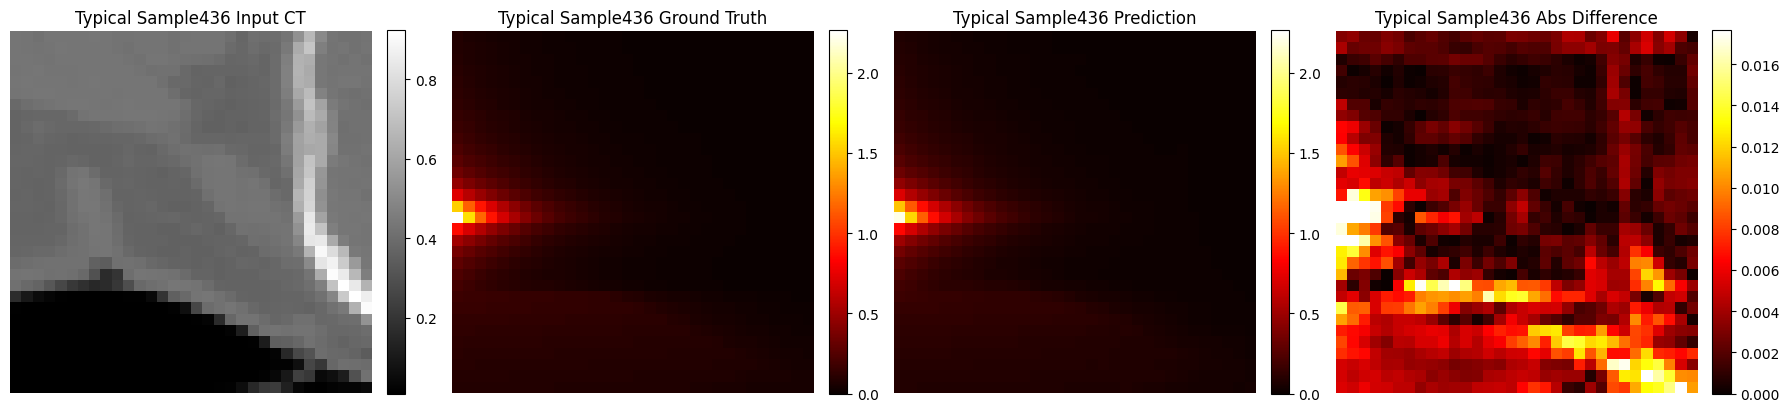

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_error_analysis/typical_sample436_cross_section.png


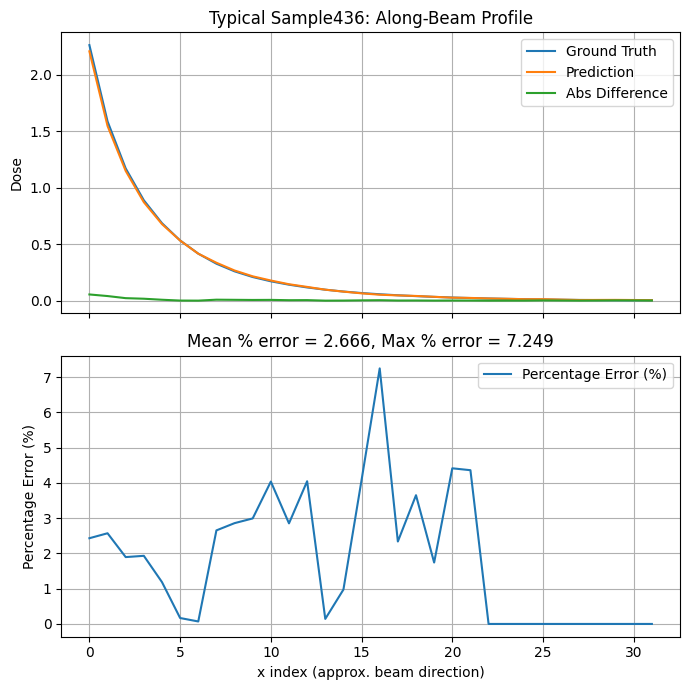

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_error_analysis/typical_sample436_along_beam_profile_with_pct_error.png


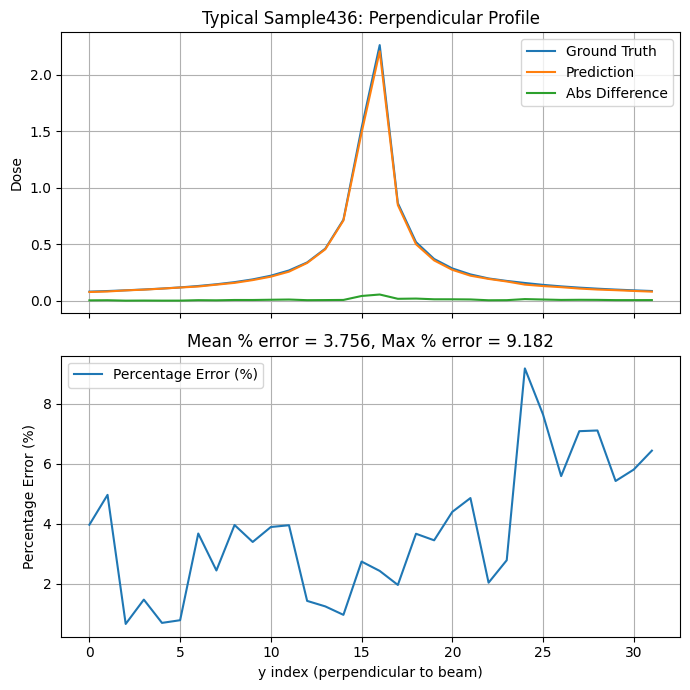

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_error_analysis/typical_sample436_perpendicular_profile_with_pct_error.png


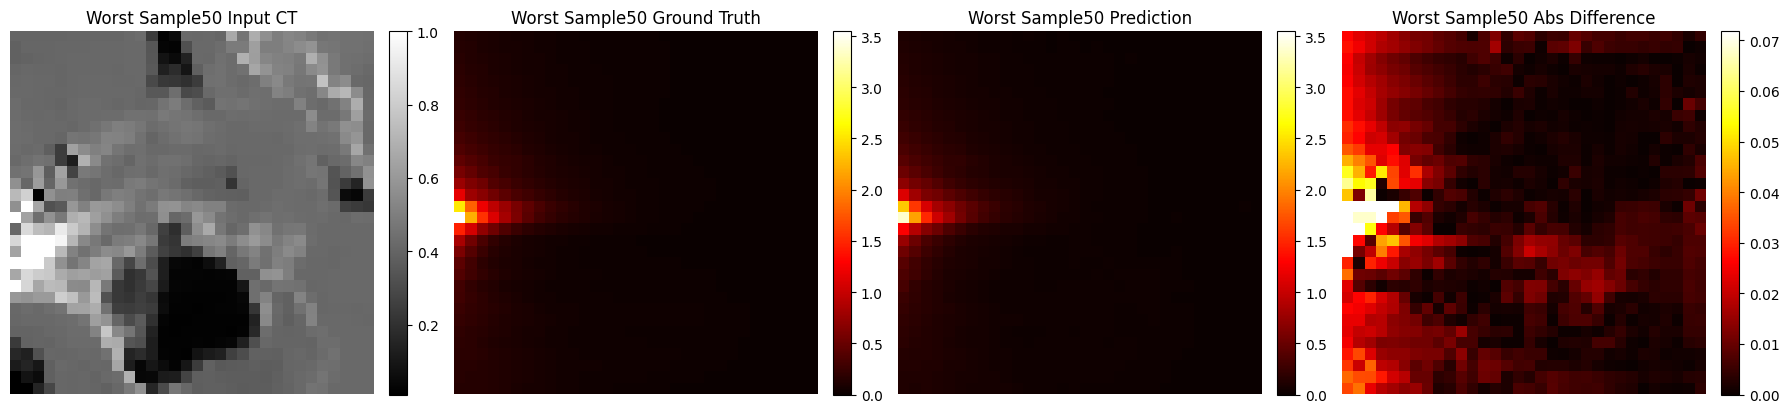

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_error_analysis/worst_sample50_cross_section.png


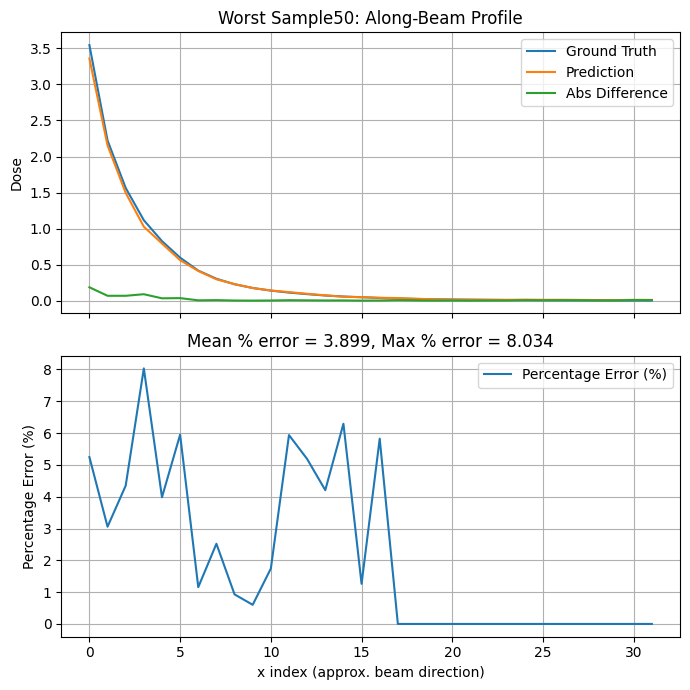

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_error_analysis/worst_sample50_along_beam_profile_with_pct_error.png


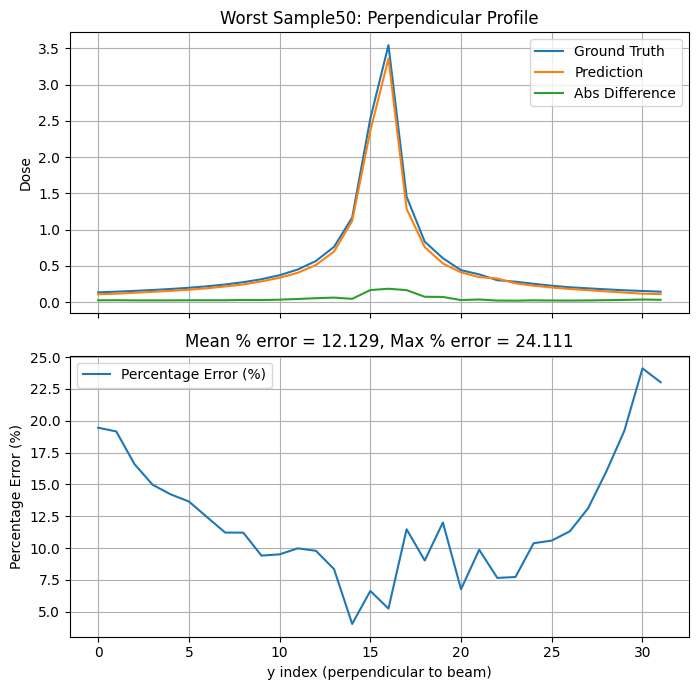

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_error_analysis/worst_sample50_perpendicular_profile_with_pct_error.png
Typical case result:
{'sample_idx': 436, 'best_slice': 16, 'peak_y': np.int64(16), 'peak_x': np.int64(0), 'gt_max': 2.2637906074523926, 'mse': 1.5669440472265705e-05, 'mae': 0.002748373430222273, 'relative_error_pct': 5.893406391143799, 'along_mean_pct_error': 2.6663693352179094, 'along_max_pct_error': 7.248647689819336, 'perp_mean_pct_error': 3.756241714581847, 'perp_max_pct_error': 9.181541442871094}

Worst case result:
{'sample_idx': 50, 'best_slice': 16, 'peak_y': np.int64(16), 'peak_x': np.int64(0), 'gt_max': 3.5455868244171143, 'mse': 0.00015973742119967937, 'mae': 0.007941384799778461, 'relative_error_pct': 16.644319534301758, 'along_mean_pct_error': 3.8989233830395866, 'along_max_pct_error': 8.033953666687012, 'perp_mean_pct_error': 12.128823295235634, 'perp_max_pct_error': 24.111024856567383}


In [14]:
# Step 14: Analyze median (typical) case and worst case

typical_result = analyze_one_case(
    val_dataset_3d,
    median_case_idx,
    flow_model,
    device,
    OUT_DIR,
    prefix=f"typical_sample{median_case_idx}"
)

worst_result = analyze_one_case(
    val_dataset_3d,
    worst_case_idx,
    flow_model,
    device,
    OUT_DIR,
    prefix=f"worst_sample{worst_case_idx}"
)

print("Typical case result:")
print(typical_result)

print("\nWorst case result:")
print(worst_result)

### Step 15 — Build a concise summary table for professor

In [15]:
# Step 15: Build a concise summary table

summary_table = pd.DataFrame([
    {
        "case_type": "typical",
        **typical_result
    },
    {
        "case_type": "worst",
        **worst_result
    }
])

summary_table_path = OUT_DIR / "phase3_typical_vs_worst_summary_table.csv"
summary_table.to_csv(summary_table_path, index=False)

print("Saved:", summary_table_path)
print(summary_table)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_error_analysis/phase3_typical_vs_worst_summary_table.csv
  case_type  sample_idx  best_slice  peak_y  peak_x    gt_max       mse  \
0   typical         436          16      16       0  2.263791  0.000016   
1     worst          50          16      16       0  3.545587  0.000160   

        mae  relative_error_pct  along_mean_pct_error  along_max_pct_error  \
0  0.002748            5.893406              2.666369             7.248648   
1  0.007941           16.644320              3.898923             8.033954   

   perp_mean_pct_error  perp_max_pct_error  
0             3.756242            9.181541  
1            12.128823           24.111025  


### Step 16 — Optional averaged profile over validation set

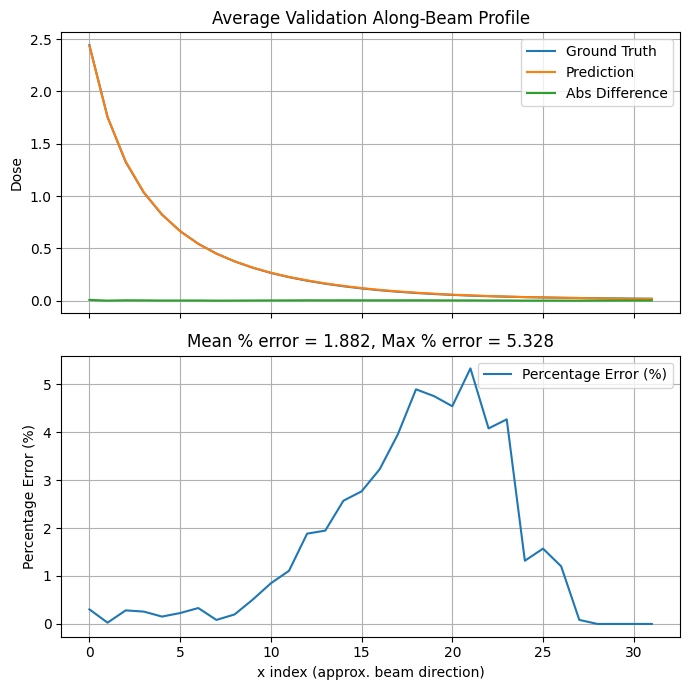

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_error_analysis/average_along_beam_profile_with_pct_error.png


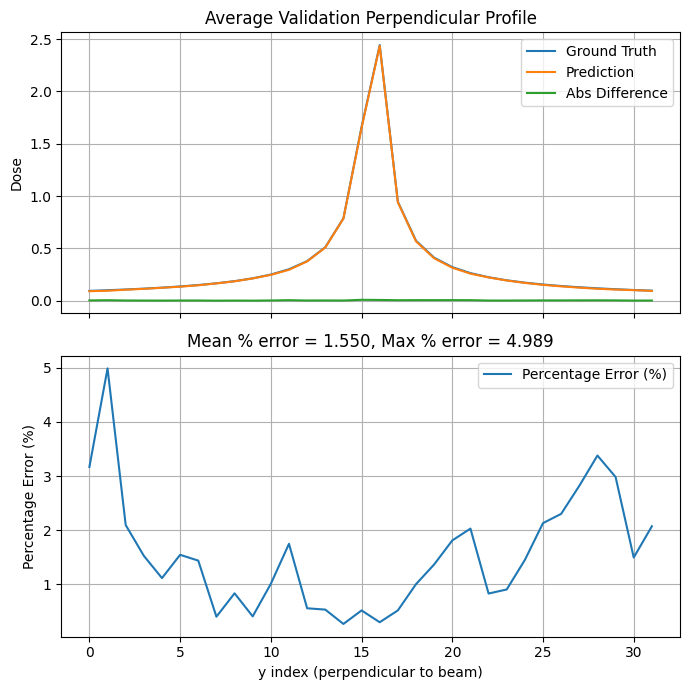

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_error_analysis/average_perpendicular_profile_with_pct_error.png
Average along-beam stats: {'mean_pct_error': 1.8817530541148568, 'max_pct_error': 5.327600479125977}
Average perpendicular stats: {'mean_pct_error': 1.549789946526289, 'max_pct_error': 4.988790035247803}


In [16]:
# Step 16: Optional averaged profiles over the validation set

all_gt_along = []
all_pred_along = []
all_gt_perp = []
all_pred_perp = []

for idx in range(len(val_dataset_3d)):
    ct_vol, gt_vol, pred_vol = get_flow_prediction(flow_model, val_dataset_3d, idx, device, n_steps=30)
    slice_idx = find_best_dose_slice_index(gt_vol)
    peak_y, peak_x = find_peak_xy(gt_vol, slice_idx)

    all_gt_along.append(gt_vol[slice_idx, peak_y, :])
    all_pred_along.append(pred_vol[slice_idx, peak_y, :])

    all_gt_perp.append(gt_vol[slice_idx, :, peak_x])
    all_pred_perp.append(pred_vol[slice_idx, :, peak_x])

avg_gt_along = np.mean(np.stack(all_gt_along), axis=0)
avg_pred_along = np.mean(np.stack(all_pred_along), axis=0)

avg_gt_perp = np.mean(np.stack(all_gt_perp), axis=0)
avg_pred_perp = np.mean(np.stack(all_pred_perp), axis=0)

avg_along_stats = plot_profile_with_percentage_error(
    avg_gt_along,
    avg_pred_along,
    OUT_DIR / "average_along_beam_profile_with_pct_error.png",
    title_main="Average Validation Along-Beam Profile",
    xlabel="x index (approx. beam direction)"
)

avg_perp_stats = plot_profile_with_percentage_error(
    avg_gt_perp,
    avg_pred_perp,
    OUT_DIR / "average_perpendicular_profile_with_pct_error.png",
    title_main="Average Validation Perpendicular Profile",
    xlabel="y index (perpendicular to beam)"
)

print("Average along-beam stats:", avg_along_stats)
print("Average perpendicular stats:", avg_perp_stats)